In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import seaborn as sns


base = Path("/home/thomas/Projects/sun_spots_pulsation_review/data/processed/sebastian_sun_spots")
ds_ids = ["DS00", "DS01","DS02", "DS03", "DS04", "DS05", "DS06", "DS07", "DS08", "DS09"]

In [12]:
mag_cols = ["mean_mag_umb", "mean_mag_pen", "mean_mag_both", "mean_mag_quiet", "mean_mag_hotspot"]
dop_cols = ["mean_dop_umb", "mean_dop_pen", "mean_dop_both", "mean_dop_quiet"]
area_cols = ['area_umb','area_pen','area_both']

mag_dfs = []
for ds in ds_ids:
    csv_path = base / ds / "metrics.csv"
    available = pd.read_csv(csv_path, nrows=0).columns
    cols = ["time_h"] + [c for c in mag_cols + dop_cols + area_cols if c in available]
    df = pd.read_csv(csv_path, nrows=250, usecols=cols)
    if "mean_mag_hotspot" not in df:
        df["mean_mag_hotspot"] = np.nan
    df["ds"] = ds
    mag_dfs.append(df)

mag_data = pd.concat(mag_dfs, ignore_index=True)
mag_data.head()

,time_h,area_umb,area_pen,area_both,mean_mag_umb,mean_mag_pen,mean_mag_both,mean_mag_quiet,mean_dop_umb,mean_dop_pen,mean_dop_both,mean_dop_quiet,mean_mag_hotspot,ds
0,0.0,572.0,5177.0,5749.0,-580.9610,-90.0598,-138.9023,-1.1876,-220.0258,-223.4314,-223.0926,668.1188,641.9320,DS00
1,0.2,555.0,5258.0,5813.0,-550.8132,-84.4671,-128.9918,-0.6028,-245.0282,-195.6367,-200.3524,501.9637,648.9160,DS00
2,0.4,584.0,5147.0,5731.0,-485.4500,-87.3461,-127.9137,0.0138,-176.0813,-193.0239,-191.2974,402.8745,646.8465,DS00
3,0.6,621.0,5210.0,5831.0,-459.9543,-91.9973,-131.1846,1.2353,-191.4076,-158.7180,-162.1995,152.1127,647.8391,DS00
4,0.8,595.0,5345.0,5940.0,-525.4353,-76.2266,-121.2231,1.3547,-186.7272,-122.2990,-128.7527,-13.4230,646.1091,DS00


In [13]:
def mag_amplitude(time_h, series):
    coeffs = np.polyfit(time_h, series, 2)
    fit = np.polyval(coeffs, time_h)
    residual = series - fit
    return residual.max() - residual.min()

In [14]:
regions = ["umb", "pen", "both", "quiet"]

amp_rows = []
for ds, df in zip(ds_ids, mag_dfs):
    for region in regions:
        dop = df[f"mean_dop_{region}"]
        mag = np.abs(df[f"mean_mag_{region}"])
        amp_rows.append({
            "ds": ds,
            "region": region,
            "dop_amplitude": dop.max() - dop.min(),
            "mag_max": mag_amplitude(df["time_h"], mag),
        })

amp_data = pd.DataFrame(amp_rows)
amp_data

,ds,region,dop_amplitude,mag_max
0,DS00,umb,958.6354,418.242935
1,DS00,pen,649.7698,99.008863
2,DS00,both,681.2533,88.017959
3,DS00,quiet,6215.2268,2.811752
4,DS01,umb,1298.6187,376.432929
5,DS01,pen,806.8194,101.453461
6,DS01,both,862.0843,148.559251
7,DS01,quiet,6002.1157,7.845132
8,DS02,umb,881.5845,307.523236
9,DS02,pen,482.5978,60.252377


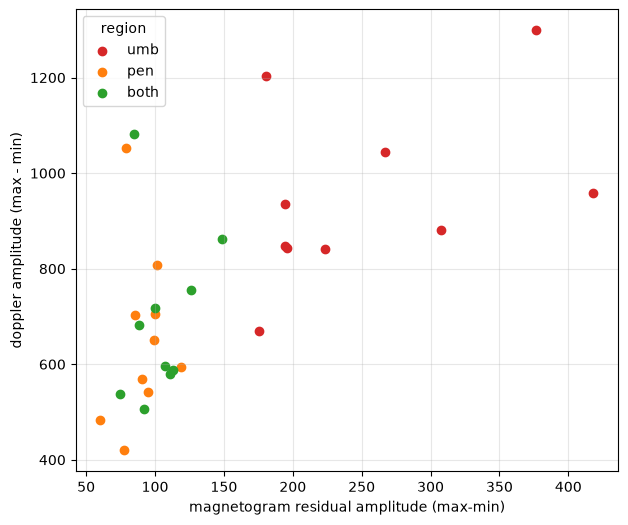

In [15]:
region_colors = {"umb": "tab:red", "pen": "tab:orange", "both": "tab:green"}

fig, ax = plt.subplots(figsize=(7, 6))
for region, color in region_colors.items():
    subset = amp_data[amp_data["region"] == region]
    ax.scatter(subset["mag_max"], subset["dop_amplitude"], label=region, color=color)

ax.set_xlabel("magnetogram residual amplitude (max-min)")
ax.set_ylabel("doppler amplitude (max - min)")
ax.legend(title="region")
ax.grid(True, alpha=0.3)
plt.show()

In [16]:
df

,time_h,area_umb,area_pen,area_both,mean_mag_umb,mean_mag_pen,mean_mag_both,mean_mag_quiet,mean_dop_umb,mean_dop_pen,mean_dop_both,mean_dop_quiet,mean_mag_hotspot,ds
0,0.0,1527.0,6524.0,8051.0,-1177.5399,-280.4385,-450.5880,-2.8948,497.3215,194.7213,252.1143,-1765.9213,-982.0944,DS09
1,0.2,1517.0,6540.0,8057.0,-1185.5850,-287.0690,-456.2447,-3.6354,473.5726,176.2665,232.2443,-1676.6019,-985.6906,DS09
2,0.4,1524.0,6440.0,7964.0,-1197.9043,-288.4462,-462.4811,-4.2966,433.0990,163.9881,215.4855,-1592.4780,-993.6753,DS09
3,0.6,1522.0,6410.0,7932.0,-1210.9827,-294.5112,-470.3647,-5.0903,428.7393,200.1451,244.0080,-1449.0899,-1002.4575,DS09
4,0.8,1512.0,6443.0,7955.0,-1226.4839,-298.1249,-474.5773,-6.5469,426.4134,161.4591,211.8187,-1349.1979,-1009.6548,DS09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,50.6,1607.0,6564.0,8171.0,-1533.1280,-402.2655,-624.6736,-3.2313,-48.0499,-93.9067,-84.8880,-221.2164,-1147.8898,DS09
246,50.8,1624.0,6591.0,8215.0,-1536.1484,-395.5983,-621.0704,-3.6753,-5.0745,-116.8612,-94.7624,2.5900,-1147.7256,DS09
247,51.0,1626.0,6496.0,8122.0,-1533.7737,-400.7744,-627.5975,-3.7940,-64.1584,-126.8598,-114.3071,77.1411,-1147.9940,DS09
248,51.2,1642.0,6558.0,8200.0,-1531.0208,-397.8158,-624.7332,-3.6032,-58.9383,-135.1714,-119.9062,311.1805,-1144.0940,DS09


In [17]:
# umb/pen amplitudes (mag and dop) vs hotspot mag amplitude, per dataset
corr_rows = []
for ds, df in zip(ds_ids, mag_dfs):
    dop_umb = df["mean_dop_umb"]
    dop_pen = df["mean_dop_pen"]
    mag_umb = np.abs(df["mean_mag_umb"])
    mag_pen = np.abs(df["mean_mag_pen"])
    mag_hotspot = np.abs(df["mean_mag_hotspot"])
    mag_amp_hotspot = mag_amplitude(df["time_h"], mag_hotspot) if mag_hotspot.notna().all() else np.nan
    umb_area = np.mean(df["area_umb"]) if "area_umb" in df else np.nan
    corr_rows.append({
        "ds": ds,
        "dop_amplitude_umb": dop_umb.max() - dop_umb.min(),
        "dop_amplitude_pen": dop_pen.max() - dop_pen.min(),
        "mag_amplitude_umb": mag_amplitude(df["time_h"], mag_umb),
        "mag_amplitude_pen": mag_amplitude(df["time_h"], mag_pen),
        "mag_amplitude_hotspot": mag_amp_hotspot,
        "Area_umb": umb_area
    })

corr_data = pd.DataFrame(corr_rows).set_index("ds")
corr_data

,dop_amplitude_umb,dop_amplitude_pen,mag_amplitude_umb,mag_amplitude_pen,mag_amplitude_hotspot,Area_umb
ds,,,,,,
DS00,958.6354,649.7698,418.242935,99.008863,113.891794,1508.616
DS01,1298.6187,806.8194,376.432929,101.453461,169.528561,871.900
DS02,881.5845,482.5978,307.523236,60.252377,NaN,2020.328
DS03,669.9201,594.2374,175.249472,118.794945,62.145514,318.176
DS04,1045.2169,705.7936,266.635354,100.191565,114.599345,587.232
DS05,847.7517,703.1938,194.206819,85.499100,81.276495,1331.776
DS06,1203.4523,1053.2843,180.338696,78.923021,93.162134,2017.132
DS07,842.2726,569.0533,223.255624,90.482708,89.471707,576.096
DS08,842.4117,542.4047,195.816138,95.121537,83.700659,909.880


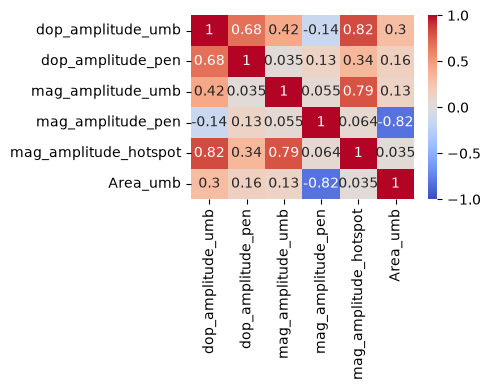

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_data.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
plt.tight_layout()
plt.show()

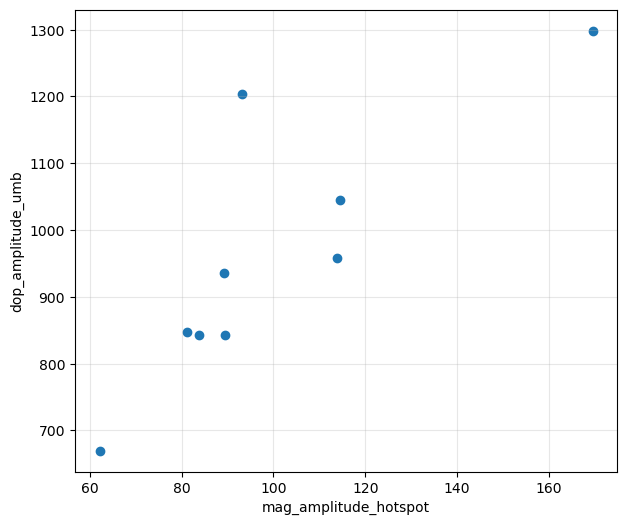

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(corr_data['mag_amplitude_hotspot'],corr_data['dop_amplitude_umb'])

ax.set_xlabel("mag_amplitude_hotspot")
ax.set_ylabel("dop_amplitude_umb")
ax.grid(True, alpha=0.3)
plt.show();

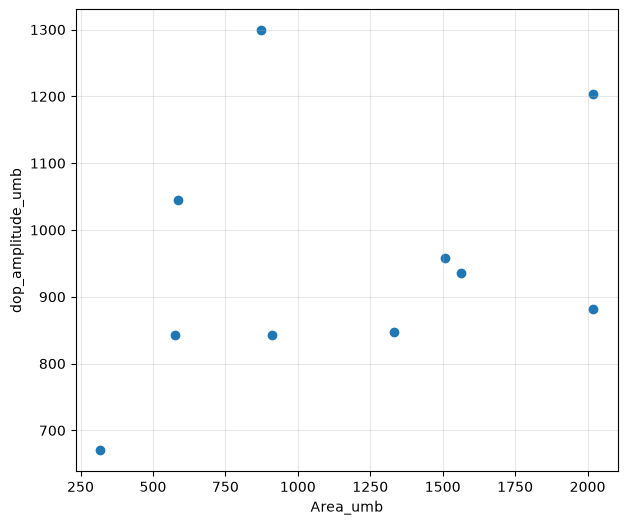

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(corr_data['Area_umb'],corr_data['dop_amplitude_umb'])

ax.set_xlabel("Area_umb")
ax.set_ylabel("dop_amplitude_umb" )
ax.grid(True, alpha=0.3)
plt.show();

## Amplitud de la oscilación: FFT y ajuste sinusoidal

`dop_amplitude = max - min` mide la excursión total de la serie, así que se lleva todo lo
que no es la oscilación: la deriva lenta, los saltos de los frames con gap y cualquier
outlier. Aquí la amplitud se estima de dos maneras que sí aíslan la componente periódica,
las dos sobre la misma serie preparada (malla uniforme, NaN interpolados, tendencia
quitada con un polinomio de grado `DETREND_DEG`):

1. **FFT** — ventana de Hann, zero-padding, y se toma el pico más alto con periodo dentro
   de `PERIOD_BAND_H` (≈ 24 h). La amplitud sale corregida por la ganancia coherente de la
   ventana, `2|X_k| / Σw`, así que queda en m/s.
2. **Ajuste sinusoidal** — `fit_diurnal` de `src/sunspot_analysis.py` ajusta
   `c + a·sin(2πt/P) + b·cos(2πt/P)` por mínimos cuadrados lineales y devuelve
   `A = hypot(a, b)` junto con `sigma_amplitude`. `P` se fija al periodo que encontró la
   FFT de cada dataset (`fit_amp_24h` repite el ajuste con 24 h exactas, como control).

Las dos son **semiamplitudes**: el pico a pico equivalente es `2A`, así que no son
comparables en valor absoluto con el `max - min` de las celdas de arriba (`maxmin_umb`
queda en la tabla para ver el factor).

Además de la umbra en absoluto se calcula `umbra − sol quieto`. La órbita geosíncrona de
SDO mete una señal de 24 h en la velocidad LOS, o sea que cualquier residuo de la
corrección de `v_SDO` cae exactamente en el periodo que estamos midiendo: si las dos
amplitudes salen parecidas la señal es umbral, y si la absoluta es mucho mayor, la mayor
parte es común a toda la caja y es instrumental.


In [22]:
import sys
import pathlib

project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

from src.sunspot_analysis import fit_diurnal, diurnal_curve, DIURNAL_PERIOD_H

# Ventana de análisis, en horas desde el primer frame. (0, 50) ≈ las 250 filas que carga
# la celda de arriba, o sea ~2 ciclos de 24 h: es el mínimo para que amplitud, fase y
# offset se separen. None = toda la serie, pero entonces la mancha cruza medio disco y
# el área media deja de ser comparable entre datasets.
WINDOW_H      = (0.0, 50.0)
PERIOD_BAND_H = (16.0, 36.0)   # dónde buscar el pico "de 24 h" en la FFT
DETREND_DEG   = 1              # 0 = sólo la media, 1 = recta, 2 = parábola
PAD_FACTOR    = 8              # zero-padding: interpola el espectro, NO añade resolución

osc_dfs = {ds: pd.read_csv(base / ds / "metrics.csv") for ds in ds_ids}


def _window(df, window=WINDOW_H):
    if window is None:
        return df
    return df[(df["time_h"] >= window[0]) & (df["time_h"] <= window[1])]


def _prepare(time_h, series, detrend_deg=DETREND_DEG):
    """Serie en malla temporal uniforme, con los NaN interpolados y sin tendencia.

    La FFT asume muestreo uniforme y el polinomio se lleva la deriva lenta, que es la
    que hace que `max - min` no sea la amplitud de nada.
    """
    t = np.asarray(time_h, dtype=float)
    y = np.asarray(series, dtype=float)
    good = np.isfinite(y)
    if good.sum() < 4:
        return np.array([]), np.array([])

    dt   = float(np.median(np.diff(t)))
    grid = np.arange(t[0], t[-1] + 0.5 * dt, dt)
    y_u  = np.interp(grid, t[good], y[good])
    return grid, y_u - np.polyval(np.polyfit(grid, y_u, detrend_deg), grid)


def fft_amplitude(time_h, series, band=PERIOD_BAND_H, pad=PAD_FACTOR):
    """Semiamplitud y periodo del pico más alto de la FFT dentro de `band`.

    Ventana de Hann para que la fuga espectral no reparta el pico entre bins vecinos, y
    la amplitud se corrige por la ganancia coherente de la ventana (`2|X_k| / sum(w)`),
    así que sale en m/s y no en cuentas de la FFT.
    """
    nan = dict(amplitude=np.nan, period_h=np.nan, n_cycles=np.nan,
               freq_per_h=np.array([]), amp=np.array([]))
    t, y = _prepare(time_h, series)
    if t.size < 8:
        return nan

    n    = t.size
    w    = np.hanning(n)
    spec = np.fft.rfft(y * w, n=pad * n)
    freq = np.fft.rfftfreq(pad * n, d=t[1] - t[0])   # ciclos / hora
    amp  = 2 * np.abs(spec) / w.sum()

    inband = (freq >= 1 / band[1]) & (freq <= 1 / band[0])
    if not inband.any():
        return nan

    k      = int(np.argmax(np.where(inband, amp, -np.inf)))
    period = 1 / freq[k]
    return dict(amplitude=float(amp[k]), period_h=float(period),
                n_cycles=float((t[-1] - t[0]) / period),
                freq_per_h=freq, amp=amp)


def sine_amplitude(time_h, series, period_h, label=""):
    """`fit_diurnal` sobre la misma serie preparada que ve la FFT.

    Devuelve el dict completo del ajuste: `amplitude` es la semiamplitud A de
    `A sin(2 pi t / P + phi)` y `sigma_amplitude` su incertidumbre — con ~2 ciclos de
    ventana esa sigma es la que dice si la amplitud se puede leer o no.
    """
    t, y = _prepare(time_h, series)
    if t.size < 8 or not np.isfinite(period_h):
        return dict(amplitude=np.nan, sigma_amplitude=np.nan, rms_residual=np.nan,
                    period_h=period_h, coefficients=np.full(3, np.nan))
    return fit_diurnal(t, y, period_h=float(period_h), label=label)

In [23]:
osc_rows, osc_series = [], {}

for ds in ds_ids:
    df = _window(osc_dfs[ds])
    t       = df["time_h"].to_numpy(dtype=float)
    dop_umb = df["mean_dop_umb"].to_numpy(dtype=float)
    dop_rel = dop_umb - df["mean_dop_quiet"].to_numpy(dtype=float)

    fft_umb = fft_amplitude(t, dop_umb)
    fft_rel = fft_amplitude(t, dop_rel)

    # El periodo del ajuste se fija al que encontró la FFT de la umbra, así las dos
    # figuras miden lo mismo. fit_amp_24h queda como control con el periodo nominal.
    period  = fft_umb["period_h"]
    fit_umb = sine_amplitude(t, dop_umb, period, label=f"{ds} umbra")
    fit_rel = sine_amplitude(t, dop_rel, period, label=f"{ds} umbra-quiet")
    fit_24  = sine_amplitude(t, dop_umb, DIURNAL_PERIOD_H, label=f"{ds} umbra 24h")

    osc_rows.append({
        "ds"           : ds,
        "area_umb"     : float(np.nanmean(df["area_umb"])),
        "span_h"       : float(t[-1] - t[0]),
        "fft_period_h" : fft_umb["period_h"],
        "n_cycles"     : fft_umb["n_cycles"],
        "fft_amp_umb"  : fft_umb["amplitude"],
        "fft_amp_rel"  : fft_rel["amplitude"],
        "fit_amp_umb"  : fit_umb["amplitude"],
        "fit_sigma_umb": fit_umb["sigma_amplitude"],
        "fit_amp_rel"  : fit_rel["amplitude"],
        "fit_sigma_rel": fit_rel["sigma_amplitude"],
        "fit_amp_24h"  : fit_24["amplitude"],
        "fit_rms_umb"  : fit_umb["rms_residual"],
        # referencia: el estimador crudo que se usaba antes (pico a pico, no semiamplitud)
        "maxmin_umb"   : float(np.nanmax(dop_umb) - np.nanmin(dop_umb)),
    })
    osc_series[ds] = dict(t=t, dop_umb=dop_umb, dop_rel=dop_rel,
                          fft_umb=fft_umb, fft_rel=fft_rel,
                          fit_umb=fit_umb, fit_rel=fit_rel)

osc_data = pd.DataFrame(osc_rows).set_index("ds")
osc_data.round(2)

,area_umb,span_h,fft_period_h,n_cycles,fft_amp_umb,fft_amp_rel,fit_amp_umb,fit_sigma_umb,fit_amp_rel,fit_sigma_rel,fit_amp_24h,fit_rms_umb,maxmin_umb
ds,,,,,,,,,,,,,
DS00,1509.57,50.0,21.14,2.37,445.32,3619.15,448.05,7.31,3571.29,44.10,390.37,80.19,958.64
DS01,871.33,50.0,23.62,2.12,564.15,3537.10,541.59,9.38,3357.80,41.90,539.72,105.12,1298.62
DS02,2009.88,50.0,23.62,2.12,375.81,2901.63,358.72,5.34,2863.71,17.20,362.16,60.71,881.16
DS03,318.42,50.0,23.62,2.12,248.27,2511.56,255.07,3.49,2499.88,13.46,255.78,39.63,669.92
DS04,587.43,50.0,23.62,2.12,444.41,3173.07,444.72,6.30,3161.64,14.53,445.98,71.75,1045.22
DS05,1331.63,50.0,23.62,2.12,324.02,3144.98,323.59,6.53,3114.15,23.16,322.02,74.02,847.75
DS06,1973.37,50.0,23.62,2.12,464.08,3552.11,473.70,7.27,3533.54,17.81,474.46,82.53,1203.45
DS07,575.98,50.0,23.62,2.12,357.17,3387.78,329.45,6.57,3202.59,41.34,328.56,73.38,842.27
DS08,911.45,50.0,25.10,1.99,356.67,3358.18,334.48,6.89,3195.59,50.97,333.60,76.73,842.41


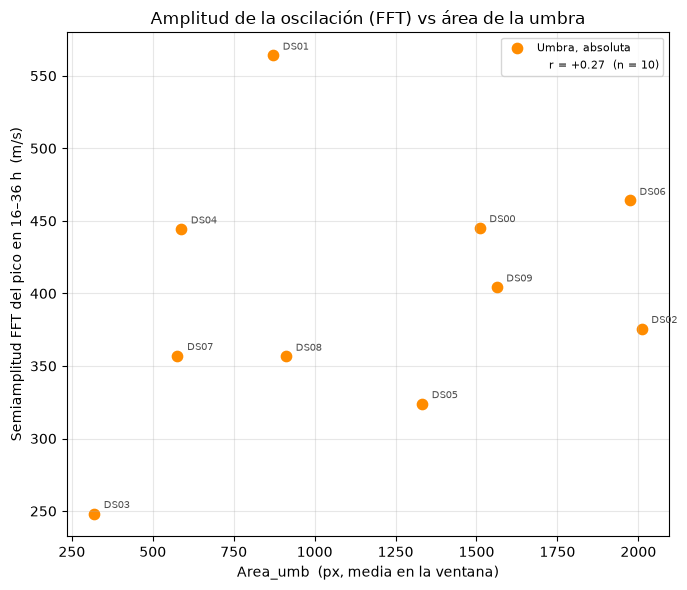

In [27]:
# --- 1) Área vs amplitud del pico de la FFT ----------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

for col, color, marker, name in [
        ("fft_amp_umb", "darkorange", "o", "Umbra, absoluta")]:
        #("fft_amp_rel", "steelblue", "s", "Umbra − sol quieto")]:
    ax.scatter(osc_data["area_umb"], osc_data[col], color=color, marker=marker, s=55, label=name)

    finite = np.isfinite(osc_data["area_umb"]) & np.isfinite(osc_data[col])
    if finite.sum() > 2:
        r = float(np.corrcoef(osc_data.loc[finite, "area_umb"], osc_data.loc[finite, col])[0, 1])
        ax.plot([], [], " ", label=f"   r = {r:+.2f}  (n = {int(finite.sum())})")

for ds, row in osc_data.iterrows():
    ax.annotate(ds, (row["area_umb"], row["fft_amp_umb"]),
                textcoords="offset points", xytext=(7, 4), fontsize=7, color="0.3")

ax.set_xlabel("Area_umb  (px, media en la ventana)")
ax.set_ylabel(f"Semiamplitud FFT del pico en {PERIOD_BAND_H[0]:g}–{PERIOD_BAND_H[1]:g} h  (m/s)")
ax.set_title("Amplitud de la oscilación (FFT) vs área de la umbra")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

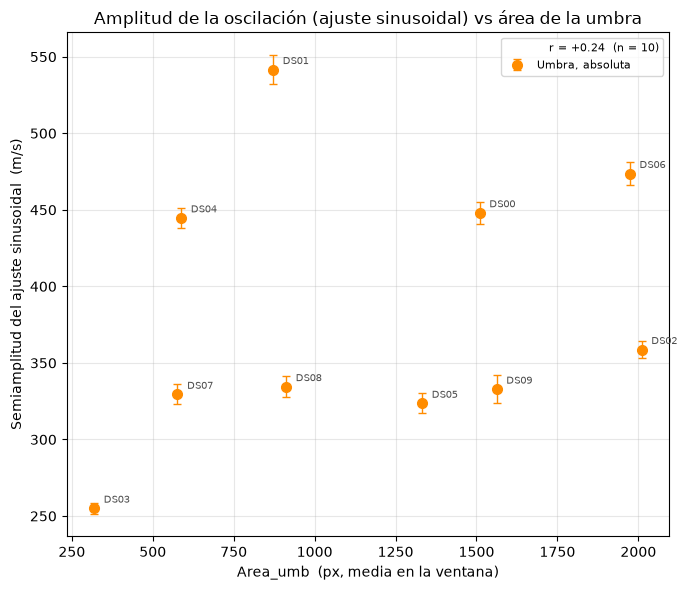

In [30]:
# --- 2) Área vs amplitud del ajuste sinusoidal -------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

for col, err, color, marker, name in [
        ("fit_amp_umb", "fit_sigma_umb", "darkorange", "o", "Umbra, absoluta")]:
       # ("fit_amp_rel", "fit_sigma_rel", "steelblue", "s", "Umbra − sol quieto")]:
    ax.errorbar(osc_data["area_umb"], osc_data[col], yerr=osc_data[err],
                fmt=marker, color=color, ms=7, lw=0, elinewidth=1, capsize=3, label=name)

    finite = np.isfinite(osc_data["area_umb"]) & np.isfinite(osc_data[col])
    if finite.sum() > 2:
        r = float(np.corrcoef(osc_data.loc[finite, "area_umb"], osc_data.loc[finite, col])[0, 1])
        ax.plot([], [], " ", label=f"   r = {r:+.2f}  (n = {int(finite.sum())})")

for ds, row in osc_data.iterrows():
    ax.annotate(ds, (row["area_umb"], row["fit_amp_umb"]),
                textcoords="offset points", xytext=(7, 4), fontsize=7, color="0.3")

ax.set_xlabel("Area_umb  (px, media en la ventana)")
ax.set_ylabel("Semiamplitud del ajuste sinusoidal  (m/s)")
ax.set_title("Amplitud de la oscilación (ajuste sinusoidal) vs área de la umbra")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Verificación obligatoria antes de leer las dos figuras de arriba: una amplitud sólo
# significa algo si la sinusoide realmente sigue a los datos. Gris = serie sin tendencia,
# naranja = curva ajustada con el periodo que encontró la FFT.
nrows, ncols = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows), sharex=True)
axes_flat = axes.flatten()

for ax, ds in zip(axes_flat, ds_ids):
    d = osc_series[ds]
    t, y = _prepare(d["t"], d["dop_umb"])
    ax.plot(t, y, color="0.55", lw=0.9, label="umbra (sin tendencia)")

    fit = d["fit_umb"]
    if np.isfinite(fit["amplitude"]):
        ax.plot(t, diurnal_curve(fit, t), color="darkorange", lw=2,
                label=f"A = {fit['amplitude']:.0f} ± {fit['sigma_amplitude']:.0f} m/s")

    ax.set_title(f"{ds} — P_fft = {d['fft_umb']['period_h']:.1f} h")
    ax.set_xlabel("Time  (h)")
    ax.set_ylabel("v  (m/s)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

for ax in axes_flat[len(ds_ids):]:
    ax.set_visible(False)

fig.suptitle("Ajuste sinusoidal por dataset (umbra, absoluta)", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

# Oscilations

In [ ]:


dfs = []
for ds in ds_ids:
    csv_path = base / ds / "plots" / "fft_peaks.csv"
    df = pd.read_csv(csv_path)
    df["ds"] = ds
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data = data[data["region"] != "Both"]
data.head(10)

,region,rank,freq_mhz,period_min,rel_amplitude,ds
0,Umbra,1,0.0139,1201.3,1.0000,DS00
1,Umbra,2,0.0046,3604.0,0.2185,DS00
2,Umbra,3,0.0247,675.8,0.1611,DS00
3,Umbra,4,0.0339,491.5,0.0467,DS00
4,Umbra,5,0.0509,327.6,0.0407,DS00
5,Penumbra,1,0.0139,1201.3,0.8152,DS00
6,Penumbra,2,0.0046,3604.0,0.3268,DS00
7,Penumbra,3,0.0247,675.8,0.1456,DS00
8,Penumbra,4,0.0370,450.5,0.0591,DS00
9,Penumbra,5,0.0725,230.0,0.0441,DS00


mean period:  1357.42 min


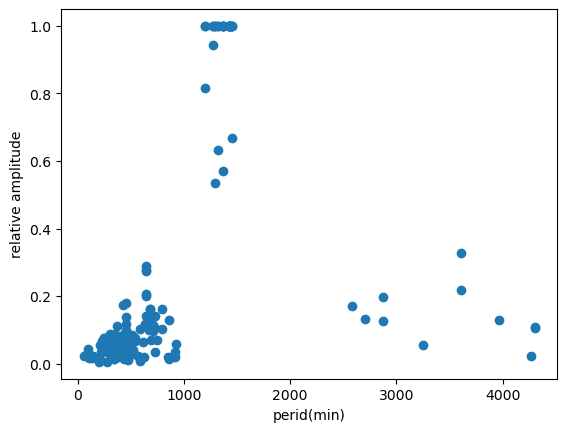

In [ ]:
plt.scatter(data['period_min'],data['rel_amplitude']);
plt.xlabel('perid(min)')
plt.ylabel('relative amplitude')

mean_period = data[data['rel_amplitude']>0.5]['period_min'].mean()
print('mean period: ',round(mean_period,2),'min')

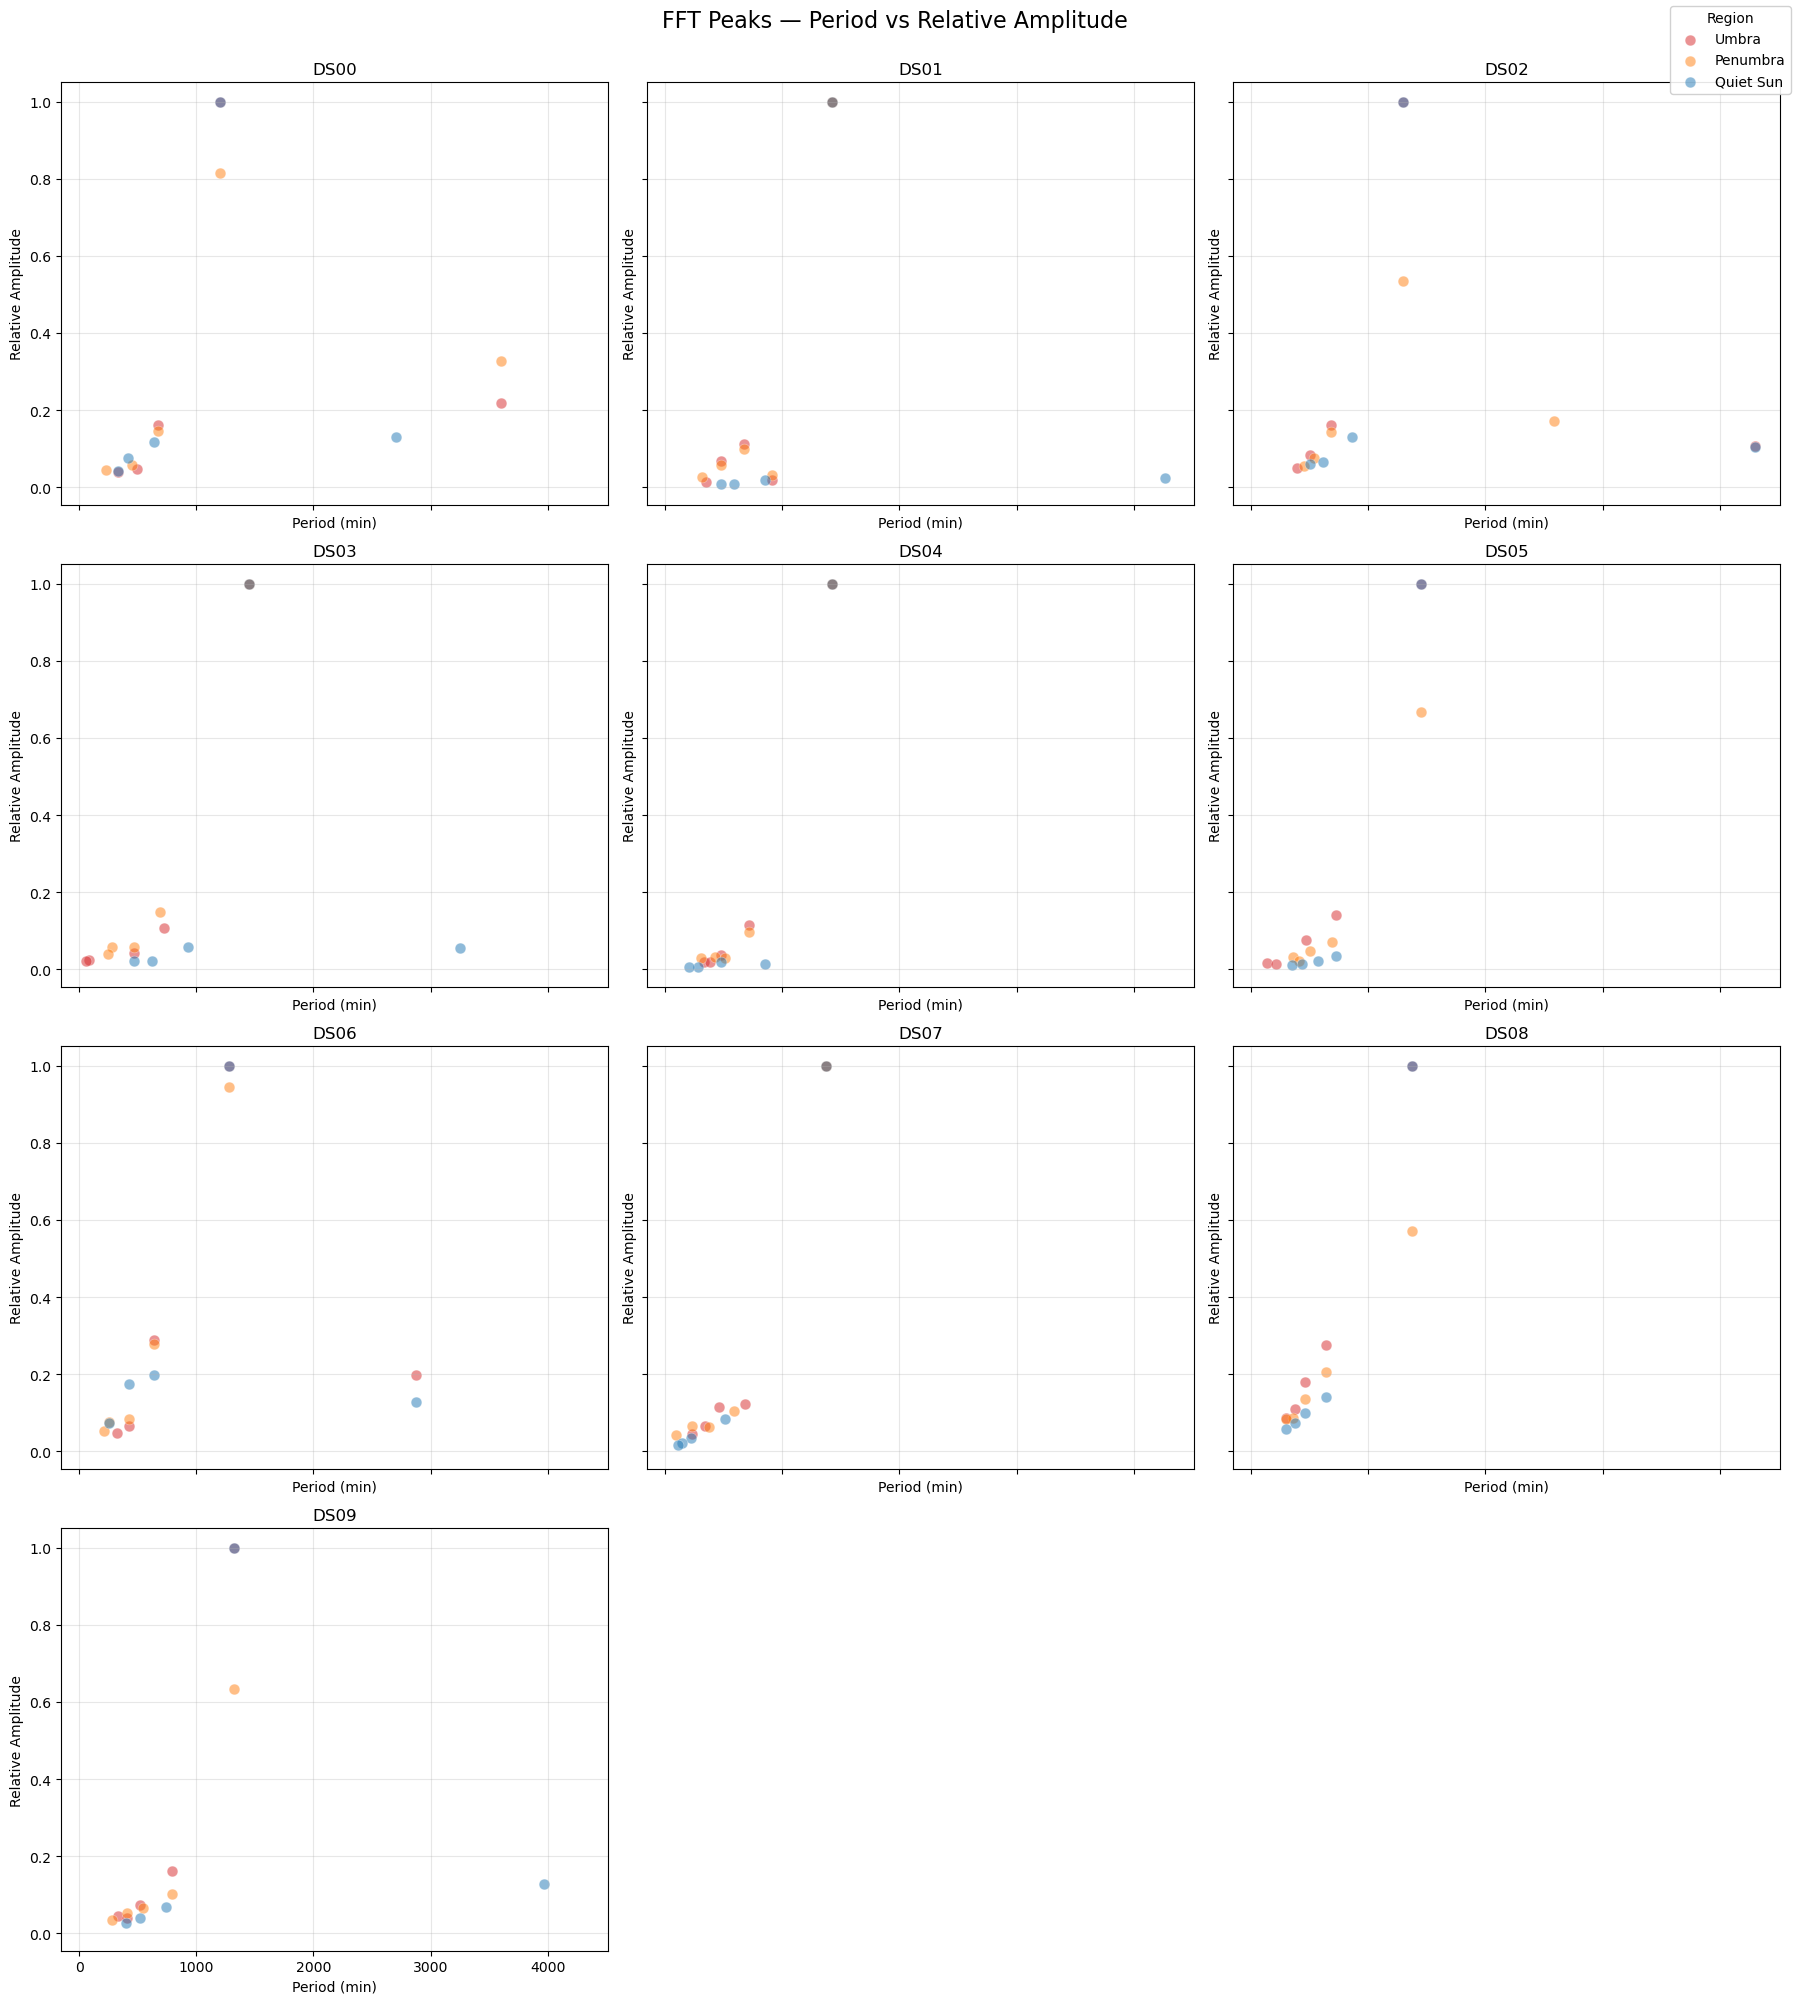

In [ ]:
region_colors = {
    "Umbra": "tab:red",
    "Penumbra": "tab:orange",
    "Quiet Sun": "tab:blue",
}

nrows, ncols = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, ds in enumerate(ds_ids):
    ax = axes_flat[i]
    subset = data[data["ds"] == ds]
    for region, color in region_colors.items():
        mask = subset["region"] == region
        if mask.any():
            ax.scatter(
                subset.loc[mask, "period_min"],
                subset.loc[mask, "rel_amplitude"],
                label=region,
                color=color,
                alpha=0.5,
                edgecolors="white",
                linewidths=0.4,
                s=60,
            )
    ax.set_title(ds)
    ax.set_xlabel("Period (min)")
    ax.set_ylabel("Relative Amplitude")
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(len(ds_ids), nrows * ncols):
    axes_flat[j].set_visible(False)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", title="Region", framealpha=0.9)
fig.suptitle("FFT Peaks — Period vs Relative Amplitude", fontsize=16,y=1)
plt.tight_layout()
plt.show()

## DS01

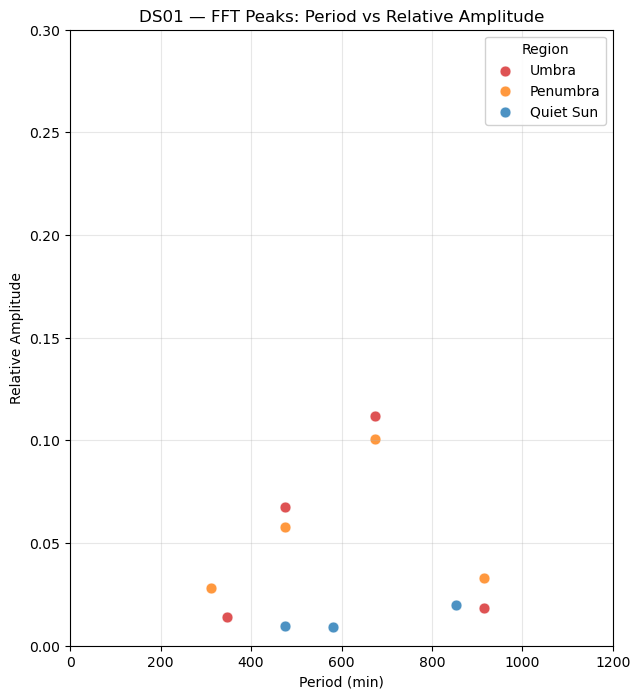

In [ ]:
ds = "DS01"

fig, ax = plt.subplots(figsize=(7, 8))
subset = data[data["ds"] == ds]
for region, color in region_colors.items():
    mask = subset["region"] == region
    if mask.any():
        ax.scatter(
            subset.loc[mask, "period_min"],
            subset.loc[mask, "rel_amplitude"],
            label=region,
            color=color,
            alpha=0.8,
            edgecolors="white",
            linewidths=0.4,
            s=60,
        )
    ax.set_title(ds+' — FFT Peaks: Period vs Relative Amplitude')
    ax.set_xlabel("Period (min)")
    ax.set_ylabel("Relative Amplitude")
    if ax is axes[0]:
        ax.set_ylabel("Relative Amplitude")
    ax.grid(True, alpha=0.3)
plt.xlim(0,1200)
plt.ylim(0,0.3)
plt.legend(title="Region", framealpha=0.9)

In [ ]:
subset

,region,rank,freq_mhz,period_min,rel_amplitude,ds
0,Umbra,1,0.0117,1422.7,1.0000,DS01
1,Umbra,2,0.0247,673.9,0.1121,DS01
2,Umbra,3,0.0351,474.2,0.0674,DS01
3,Umbra,4,0.0182,914.6,0.0184,DS01
4,Umbra,5,0.0482,346.1,0.0141,DS01
5,Penumbra,1,0.0117,1422.7,1.0000,DS01
6,Penumbra,2,0.0247,673.9,0.1006,DS01
7,Penumbra,3,0.0351,474.2,0.0578,DS01
8,Penumbra,4,0.0182,914.6,0.0329,DS01
9,Penumbra,5,0.0534,312.3,0.0280,DS01


se nota un pico unico para la umbra y la penumbra en $T(min) = 673.9$ y posiblemente uno en $T(min) = 474.2$ pero el Qsun tambien lo tiene, con respecto a la mas predumeante de la umbra, penumbra es $T(min) = 1422.7$ que coincide con la del analisis grafico y del Qsun

## DS03

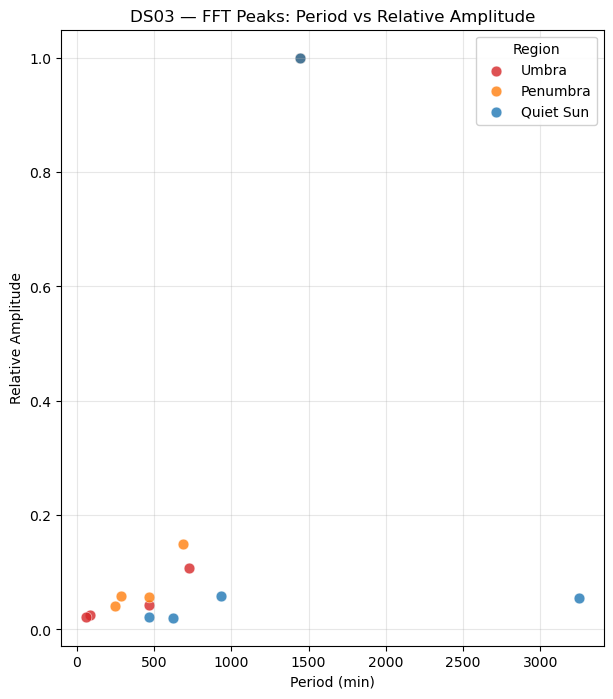

In [ ]:
ds = "DS03"

fig, ax = plt.subplots(figsize=(7, 8))

subset = data[data["ds"] == ds]

for region, color in region_colors.items():
    mask = subset["region"] == region
    if mask.any():
        ax.scatter(
            subset.loc[mask, "period_min"],
            subset.loc[mask, "rel_amplitude"],
            label=region,
            color=color,
            alpha=0.8,
            edgecolors="white",
            linewidths=0.4,
            s=60,
        )
    ax.set_title(ds+' — FFT Peaks: Period vs Relative Amplitude')
    ax.set_xlabel("Period (min)")
    ax.set_ylabel("Relative Amplitude")
    if ax is axes[0]:
        ax.set_ylabel("Relative Amplitude")
    ax.grid(True, alpha=0.3)

plt.legend(title="Region", framealpha=0.9)

In [ ]:
subset

,region,rank,freq_mhz,period_min,rel_amplitude,ds
0,Umbra,1,0.0117,1422.7,1.0000,DS01
1,Umbra,2,0.0247,673.9,0.1121,DS01
2,Umbra,3,0.0351,474.2,0.0674,DS01
3,Umbra,4,0.0182,914.6,0.0184,DS01
4,Umbra,5,0.0482,346.1,0.0141,DS01
5,Penumbra,1,0.0117,1422.7,1.0000,DS01
6,Penumbra,2,0.0247,673.9,0.1006,DS01
7,Penumbra,3,0.0351,474.2,0.0578,DS01
8,Penumbra,4,0.0182,914.6,0.0329,DS01
9,Penumbra,5,0.0534,312.3,0.0280,DS01


# Raw data doplergram comparison

In [ ]:
#%load_ext autoreload   
#%autoreload 2

import sys
import pathlib

project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.sunspot_analysis import (
    verify_cadence,
    load_and_mask,
    plot_calibration_frame,
    plot_histogram,
    plot_magnetogram_masks,
    plot_area,
    compute_metrics,
    save_metrics_csv,
    plot_ffts_separate,
    plot_ffts_combined,
    save_animation,
)

def plot_time_series(
    data: dict,
    metrics: dict,
    DS0N_NAME:str
) -> None:

    time_h = data['time_h']


    ylabel_dop =  'Mean velocity  (m/s)'

    series = [
        ('Umbra',      metrics['mean_dop_umb'],   'red'),
        ('Penumbra',   metrics['mean_dop_pen'],   'blue'),
        ('Both',       metrics['mean_dop_both'],  'purple'),
        ('Quiet Sun',  metrics['mean_dop_quiet'], 'black'),
    ]

    fig,  ax2 = plt.subplots(1, 1, figsize=(12, 6), sharex=True)
    for name, dop, color in series:
        ax2.plot(time_h, dop, color=color, lw=0.8, label=name)

 
    ax2.set_ylabel(ylabel_dop); ax2.set_xlabel('Time  (h)')
    ax2.set_title('Mean dopplergram uncorrected'+' '+DS0N_NAME,)
    ax2.grid(alpha=0.3); ax2.legend()

    plt.tight_layout()
    plt.show()
    plt.close(fig)

Raw data dir : ../data/raw/sebastian_sun_spots/DS00


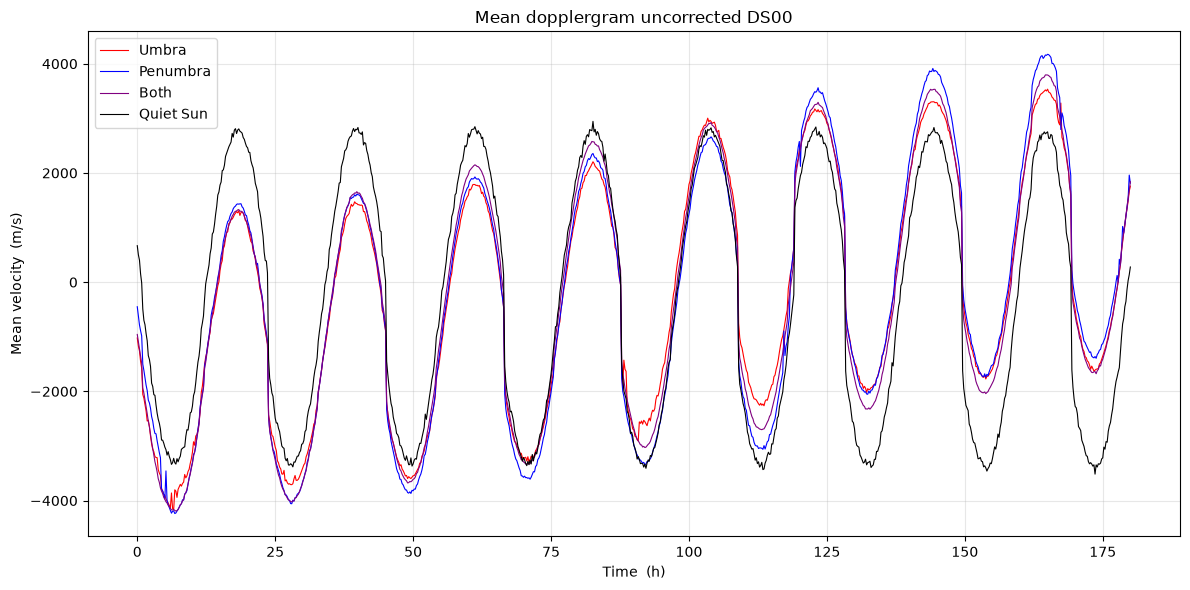

Raw data dir : ../data/raw/sebastian_sun_spots/DS01


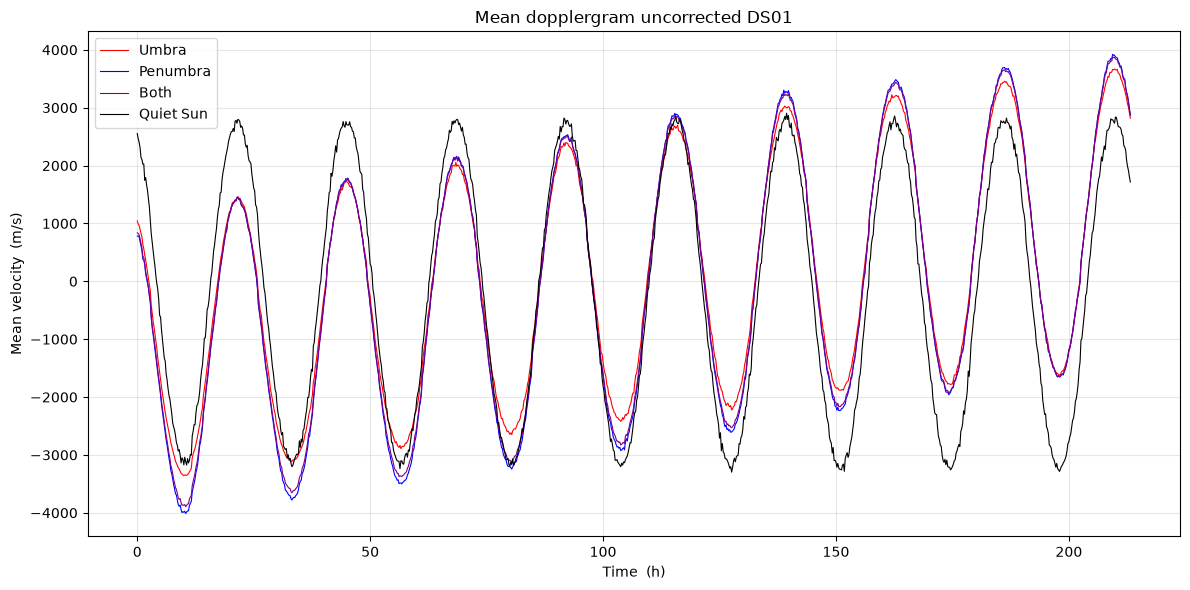

Raw data dir : ../data/raw/sebastian_sun_spots/DS03


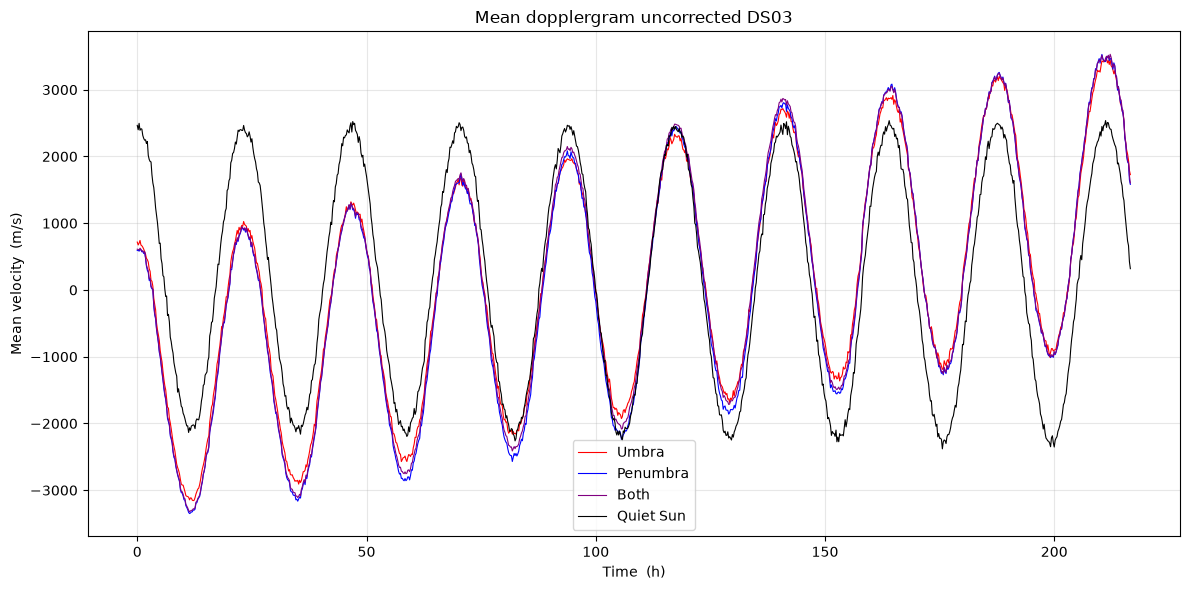

Raw data dir : ../data/raw/sebastian_sun_spots/DS04


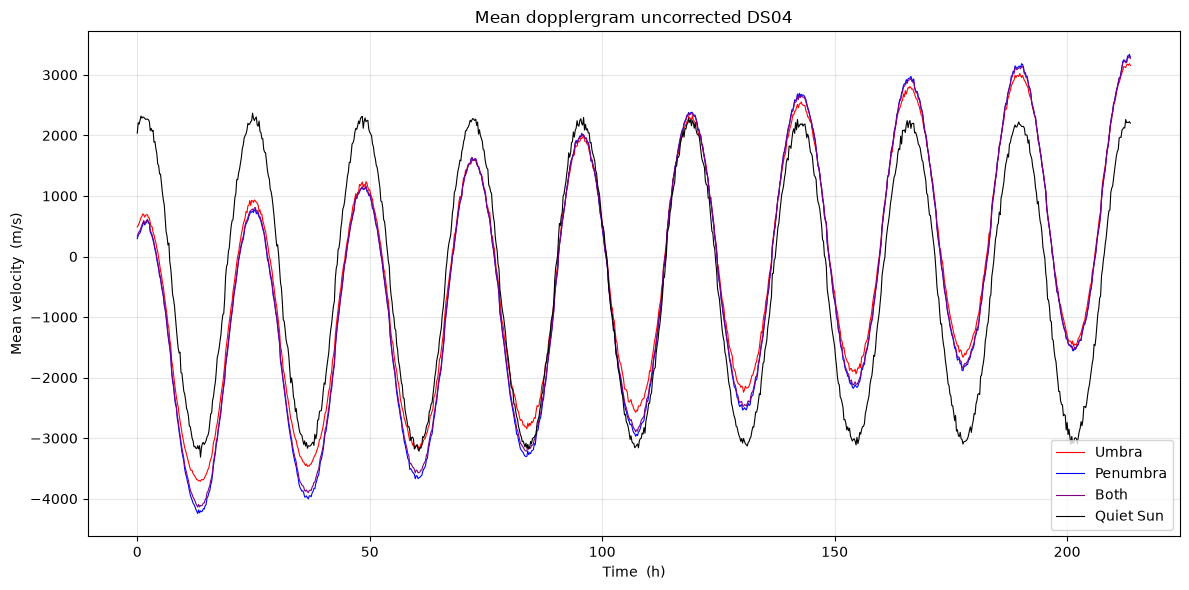

Raw data dir : ../data/raw/sebastian_sun_spots/DS05


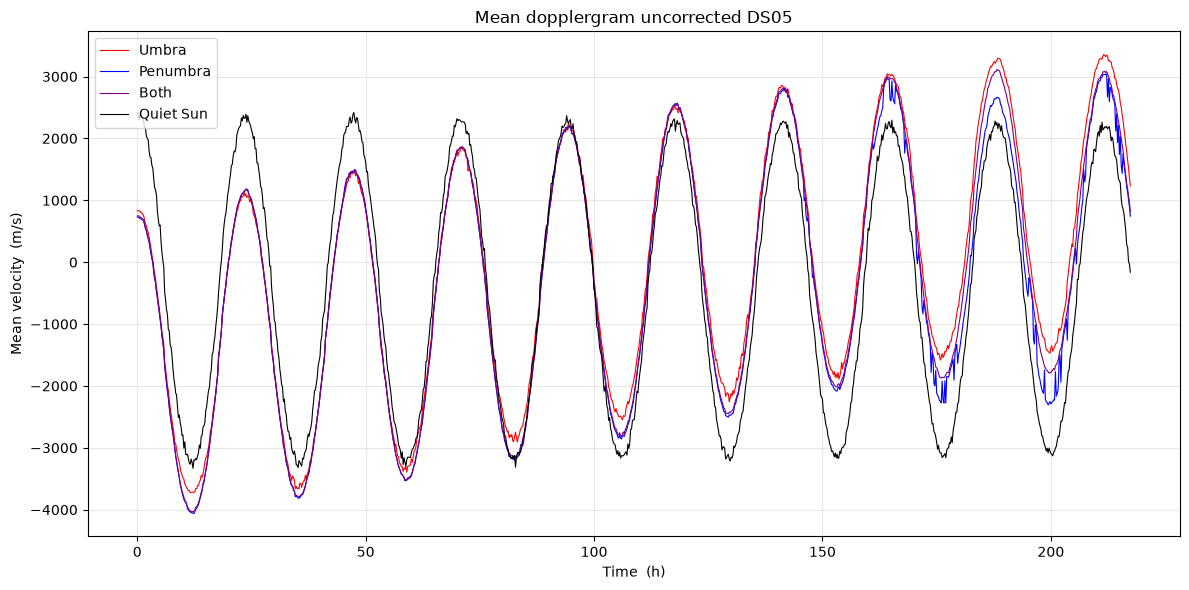

In [ ]:
DS0N_list = ['DS00','DS01','DS03','DS04','DS05']
for DS0N_NAME in DS0N_list:
    raw_dir_01      = pathlib.Path('../data/raw/sebastian_sun_spots') / DS0N_NAME
    processed_dir_01 = pathlib.Path('../data/processed/sebastian_sun_spots') / DS0N_NAME
    plots_dir_01    = processed_dir_01 / 'plots'

    print('Raw data dir :', raw_dir_01)
    mag_filter_01 = lambda x : x>500

    data = load_and_mask(
        ds_dir          = raw_dir_01,
        umbra_thresh    = 30_000,   # continuum DN — pixels below this → umbra
        penumbra_thresh = 50_000,   # continuum DN — upper bound for penumbra,
        mag_filter=mag_filter_01,
        cadence_s       = 720,
        raw_dopler = True
    )

    metrics = compute_metrics(data)

    plot_time_series(data, metrics, DS0N_NAME)

In [ ]:
# TODO compose the previos code to make a comparaison for every ds0n of uncorrected doplergram data 
# also make the commit descibing this plot

probably the effect is given by the position of the sun spots in each limb note that there is a clear trend were at the midle the diference bteween quiet and sunspot is minimal 